# Plot Residual Bathymetry Contours per Seamount

This notebook reads seamount bounding boxes and base depths from an Excel file,
then plots each seamount's region on the ORS residual bathymetry grid with:
- **Red–Blue background**: residual bathymetry (observed − regional)
- **Dashed black contour**: base depth of the edifice used for volume calculation
- **Yellow box**: seamount bounding box from the Excel file

**Required inputs:**
- `{grdfile}_residual.grd` — produced by the ORS step in `IHotspotVolume_notebook.ipynb`
- `Balleny_volume_full_results.xlsx` — Excel table with seamount names, bounding boxes, and base depths

## Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from grd_utils import grdread2

print('Imports done.')

Imports done.


## Parameters

In [2]:
# Grid name (without extension) — must match the one used in IHotspotVolume_notebook
grdname = 'Balleny'
grdfile = grdname + '.grd'

# Excel file with seamount metadata
excel_file = 'Balleny_volume_full_results.xlsx'

# Buffer around bounding box (degrees)
buf = 0.3

# Output directory for saved figures
outdir = 'results'
os.makedirs(outdir, exist_ok=True)

print(f'Grid  : {grdfile}')
print(f'Excel : {excel_file}')
print(f'Output: {outdir}/')

Grid  : Balleny.grd
Excel : Balleny_volume_full_results.xlsx
Output: results/


## Load Residual Grid & Excel Table

In [11]:
# Load residual bathymetry grid
Xres, Yres, Zres = grdread2(f'{grdfile}_residual.grd')
print(f'Residual grid loaded: {Zres.shape[1]} x {Zres.shape[0]} nodes')
print(f'  Lon: {Xres.min():.3f} to {Xres.max():.3f}')
print(f'  Lat: {Yres.min():.3f} to {Yres.max():.3f}')
print(f'  Z  : {np.nanmin(Zres):.0f} to {np.nanmax(Zres):.0f} m')

# Load seamount table
df = pd.read_excel(excel_file)
print(f'\nSeamount table loaded: {len(df)} rows')
print(df[['seamount_name', 'lat_min', 'lat_max', 'lon_min', 'lon_max', 'base_depth_m']].to_string(index=False))

Residual grid loaded: 508 x 448 nodes
  Lon: 147.050 to 163.950
  Lat: -46.950 to -32.050
  Z  : -1599 to 6221 m

Seamount table loaded: 10 rows
seamount_name    lat_min    lat_max    lon_min    lon_max  base_depth_m
      Cascade -44.202084 -43.672908 150.179705 150.748387         -2500
       Quilty -43.147963 -42.715359 151.265627 151.811643         -4000
      Maugean -41.400000 -41.017042 152.476982 153.153777         -4800
   Lanceolata -40.887716 -40.141234 153.139479 153.798521         -4800
     Janszoon -39.796307 -39.351047 154.084830 154.642100         -4400
       Nimbus -40.259030 -39.407919 153.446230 154.150000         -4400
       Awatea -36.639721 -36.165768 158.045633 158.526610         -4800
    Heemskirk -36.579169 -36.136625 159.760806 160.139614         -4800
     Funereus -36.433862 -36.094293 158.788114 159.088017         -4800
       Zeehan -36.496309 -36.070136 159.446470 159.824474         -4800


## Plot Each Seamount

For each row in the Excel table, crops the residual grid to the seamount bounding box and plots:
- Residual bathymetry (coloured background)
- Base depth contour (dashed black line)
- Bounding box (yellow rectangle)

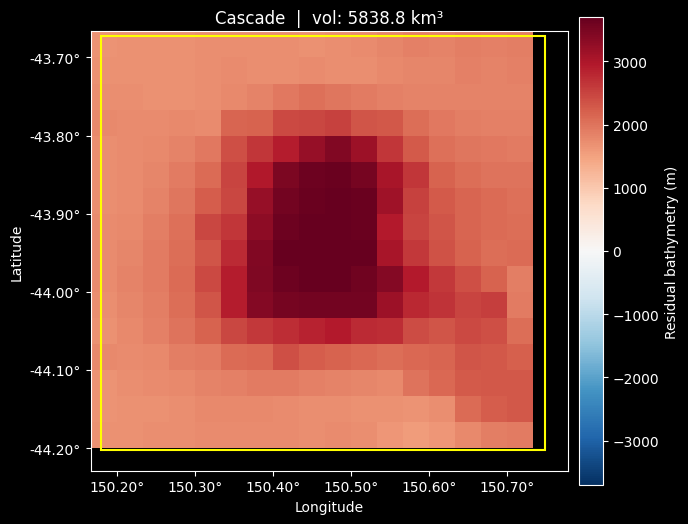

Cascade: vol = 5838.8 km³  |   →  saved to results/Balleny.grd_Cascade_residual_contour.png


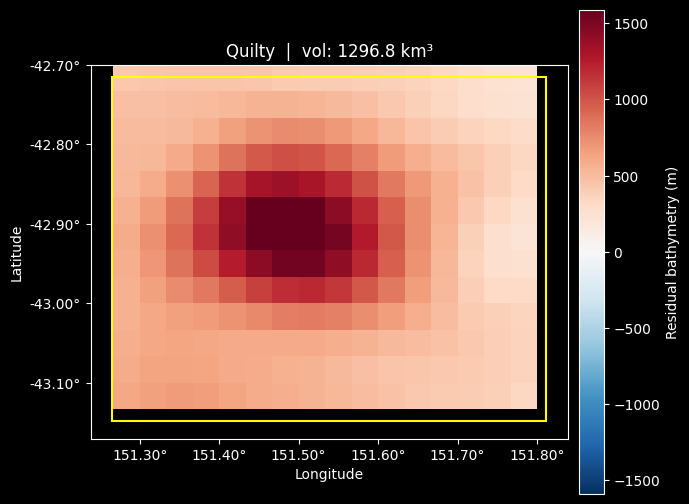

Quilty: vol = 1296.8 km³  |   →  saved to results/Balleny.grd_Quilty_residual_contour.png


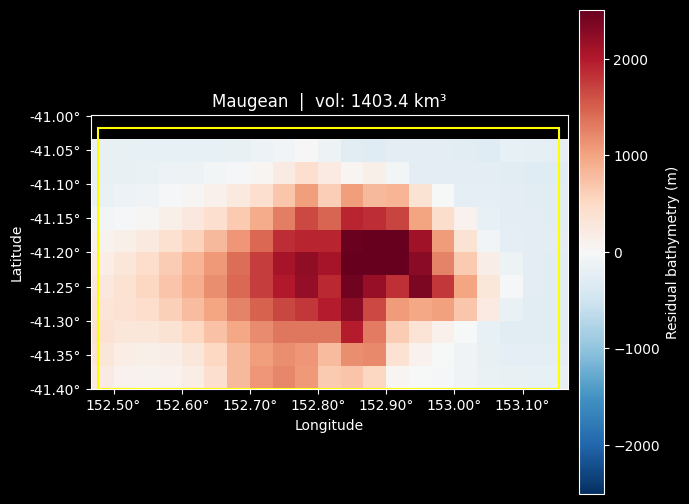

Maugean: vol = 1403.4 km³  |   →  saved to results/Balleny.grd_Maugean_residual_contour.png


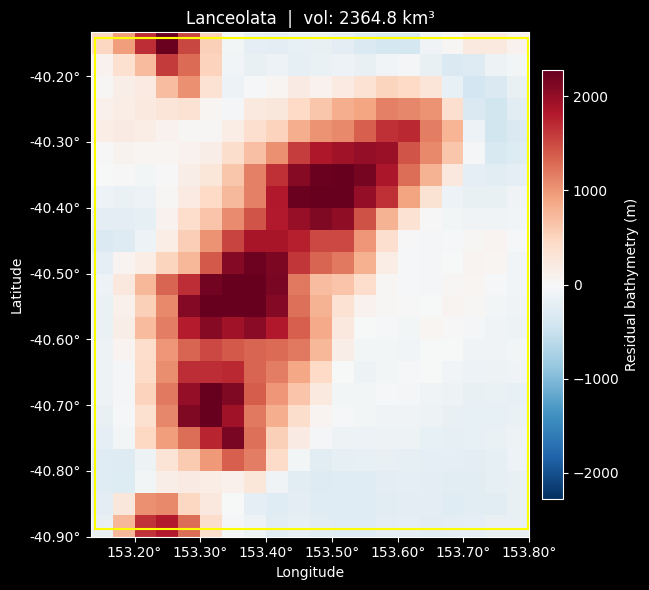

Lanceolata: vol = 2364.8 km³  |   →  saved to results/Balleny.grd_Lanceolata_residual_contour.png


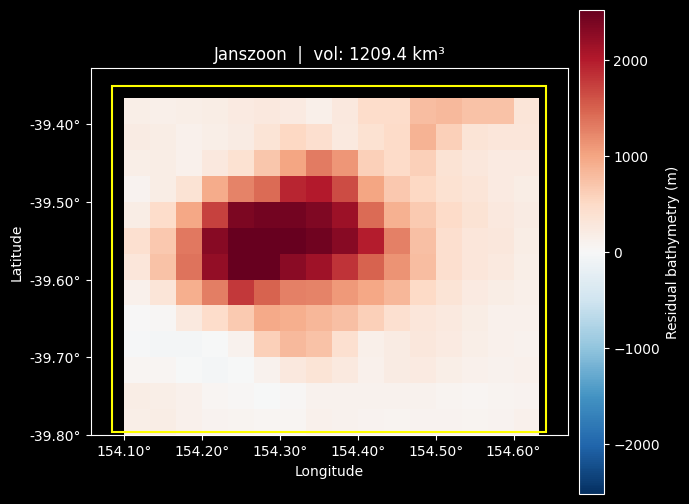

Janszoon: vol = 1209.4 km³  |   →  saved to results/Balleny.grd_Janszoon_residual_contour.png


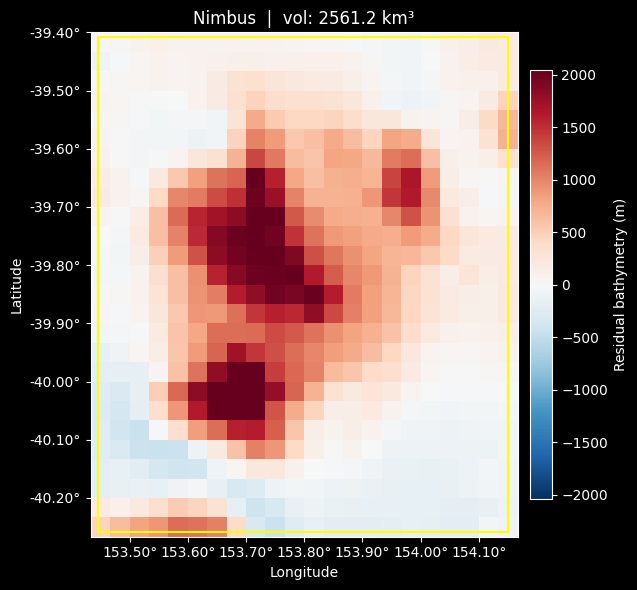

Nimbus: vol = 2561.2 km³  |   →  saved to results/Balleny.grd_Nimbus_residual_contour.png


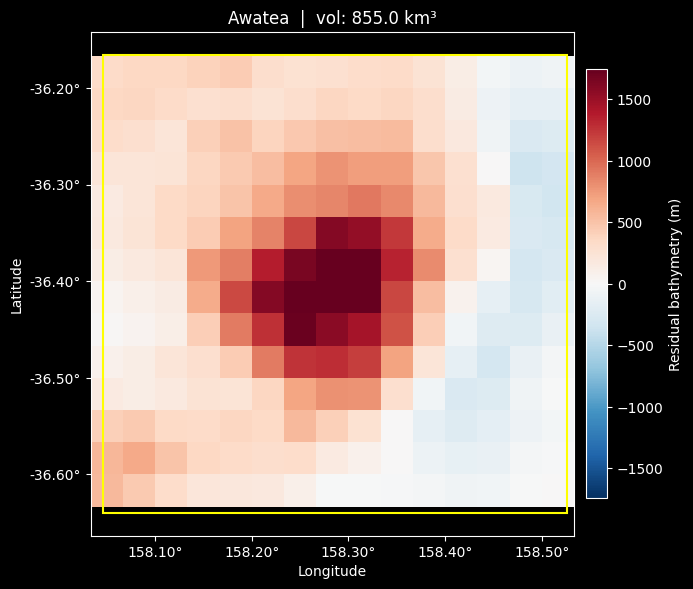

Awatea: vol = 855.0 km³  |   →  saved to results/Balleny.grd_Awatea_residual_contour.png


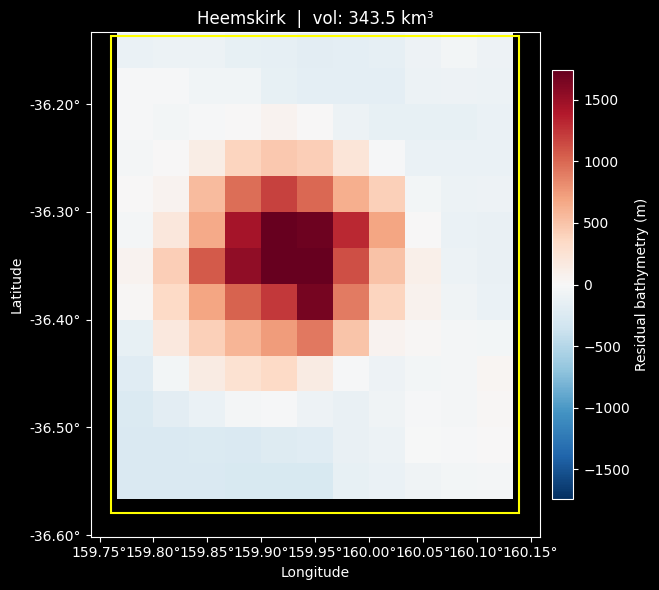

Heemskirk: vol = 343.5 km³  |   →  saved to results/Balleny.grd_Heemskirk_residual_contour.png


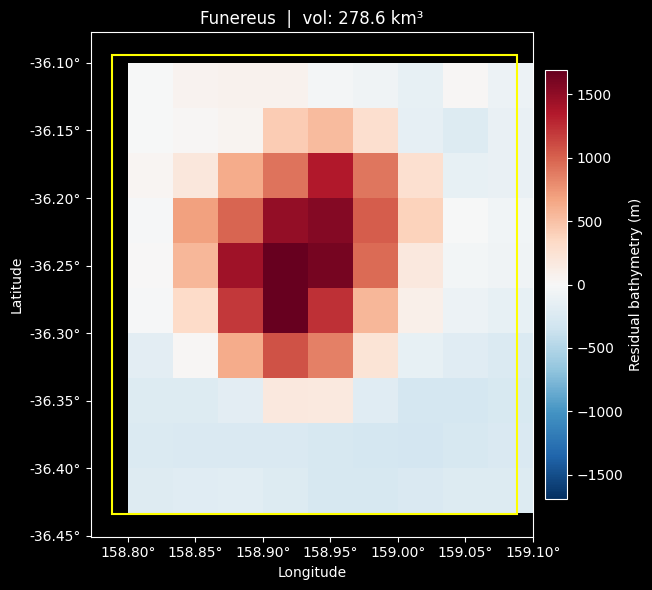

Funereus: vol = 278.6 km³  |   →  saved to results/Balleny.grd_Funereus_residual_contour.png


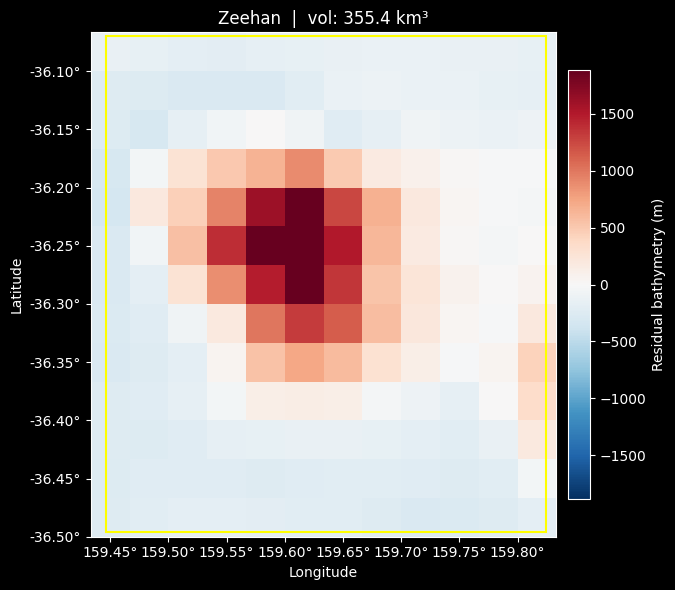

Zeehan: vol = 355.4 km³  |   →  saved to results/Balleny.grd_Zeehan_residual_contour.png


In [22]:
volumes = []  # collect results for summary table

for _, row in df.iterrows():
    name     = row['seamount_name']
    lat_min  = row['lat_min']
    lat_max  = row['lat_max']
    lon_min  = row['lon_min']
    lon_max  = row['lon_max']
    base_dep = row['base_depth_m']

    # Crop residual grid to seamount bounding box + buffer
    mask_x = (Xres >= lon_min) & (Xres <= lon_max)
    mask_y = (Yres >= lat_min) & (Yres <= lat_max)
    Xc = Xres[mask_x]
    Yc = Yres[mask_y]
    Zc = Zres[np.ix_(mask_y, mask_x)]

    if Xc.size == 0 or Yc.size == 0:
        print(f'WARNING: {name} bounding box outside residual grid — skipping.')
        continue

    # ── Volume calculation ────────────────────────────────────────────────────
    # Cell dimensions in degrees
    dx_deg = float(Xc[1] - Xc[0])
    dy_deg = float(Yc[1] - Yc[0])
    R = 6371.0  # Earth radius in km

    # Cell area varies with latitude (geographic grid)
    dy_km = dy_deg * (np.pi / 180.0) * R
    lat_rad = np.deg2rad(Yc)
    dx_km = dx_deg * (np.pi / 180.0) * R * np.cos(lat_rad)   # shape: (ny,)
    cell_area = np.outer(dx_km, np.ones(len(Xc))) * dy_km     # shape: (ny, nx)

    # Only count residual height above base_depth (positive edifice signal)
    Zedifice = np.where(Zc > 0, Zc - 50, 0.0)
    Zedifice = np.where(np.isnan(Zc), 0.0, Zedifice)

    # Volume in km³  (height in metres → divide by 1000 to get km)
    vol_km3 = float(np.sum(Zedifice * cell_area) / 1e3)
    volumes.append({'seamount_name': name, 'vol_residual_km3': round(vol_km3, 2)})

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    vmax = np.nanpercentile(np.abs(Zc), 98)
    im = ax.pcolormesh(Xc, Yc, Zc, cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, shading='auto')
    cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label('Residual bathymetry (m)', fontsize=10)

    # Base depth contour
    cs = ax.contour(Xc, Yc, Zc, levels=[base_dep],
                    colors='black', linewidths=1.5, linestyles='--')
    ax.clabel(cs, fmt=f'{base_dep:.0f} m', fontsize=8)

    # Bounding box
    rect = plt.Rectangle((lon_min, lat_min),
                          lon_max - lon_min, lat_max - lat_min,
                          edgecolor='yellow', facecolor='none',
                          linewidth=1.5, linestyle='-')
    ax.add_patch(rect)

    ax.set_title(f'{name}  |  vol: {vol_km3:.1f} km³', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f°'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f°'))
    ax.set_aspect('equal')

    plt.tight_layout()
    outpath = os.path.join(outdir, f'{grdfile}_{name}_residual_contour.png')
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{name}: vol = {vol_km3:.1f} km³  |   →  saved to {outpath}')

## Overview — All Seamounts on One Map

## Volume Summary Table

In [24]:
# Merge calculated volumes with original Excel table
df_vol = pd.DataFrame(volumes)
df_summary = df.merge(df_vol, on='seamount_name', how='left')

# Print summary
print(df_summary[['seamount_name', 'base_depth_m', 'vol_residual_km3', 'excel_volume_km3']].to_string(index=False))
print(f'\nTotal residual volume: {df_summary["vol_residual_km3"].sum():.1f} km³')

# Update vol_residual_km3 column in the original Excel file
with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
    df_summary.to_excel(writer, index=False, sheet_name='Sheet1')
print(f'Updated {excel_file}')

seamount_name  base_depth_m  vol_residual_km3  excel_volume_km3
      Cascade         -2500           5838.85       1289.249248
       Quilty         -4000           1296.78        363.623539
      Maugean         -4800           1403.37       1713.334655
   Lanceolata         -4800           2364.75       2301.553351
     Janszoon         -4400           1209.36        909.580355
       Nimbus         -4400           2561.22       2477.201375
       Awatea         -4800            855.04       1086.223435
    Heemskirk         -4800            343.46        421.857467
     Funereus         -4800            278.59        381.769652
       Zeehan         -4800            355.37        493.873319

Total residual volume: 16506.8 km³
Updated Balleny_volume_full_results.xlsx


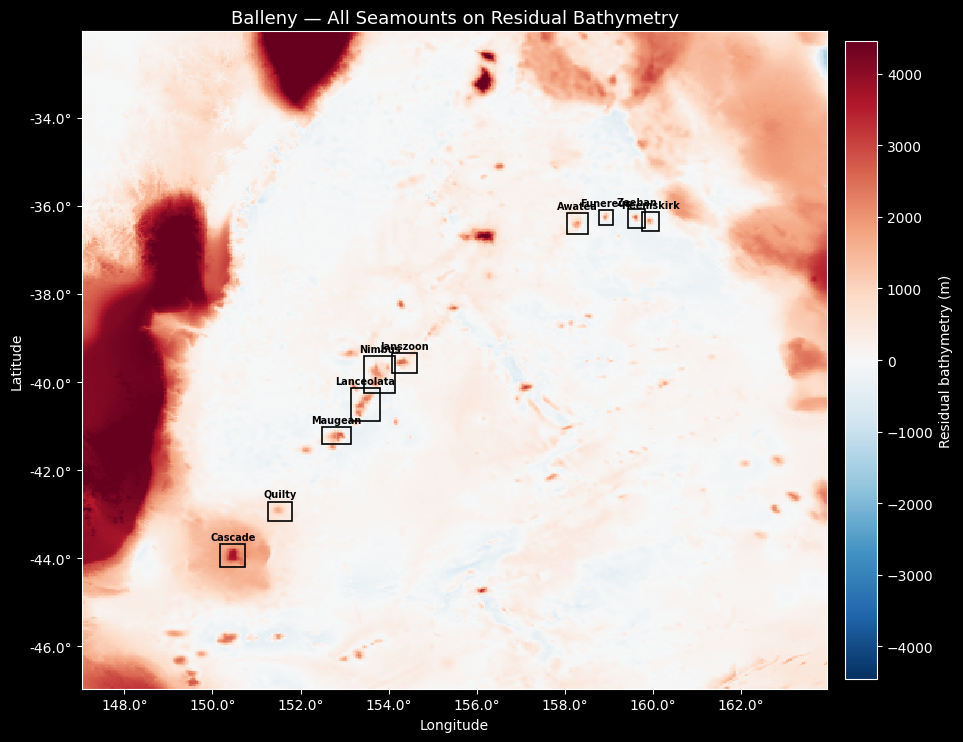

Overview saved to results/Balleny.grd_all_seamounts_overview.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

# Full residual grid background
vmax = np.nanpercentile(np.abs(Zres), 98)
im = ax.pcolormesh(Xres, Yres, Zres, cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, shading='auto')
cb = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
cb.set_label('Residual bathymetry (m)', fontsize=10)

# Draw each seamount bounding box and label
for _, row in df.iterrows():
    name    = row['seamount_name']
    lat_min = row['lat_min']
    lat_max = row['lat_max']
    lon_min = row['lon_min']
    lon_max = row['lon_max']

    rect = plt.Rectangle((lon_min, lat_min),
                          lon_max - lon_min, lat_max - lat_min,
                          edgecolor='black', facecolor='none',
                          linewidth=1.2, linestyle='-')
    ax.add_patch(rect)
    ax.text((lon_min + lon_max) / 2, lat_max + 0.05, name,
            ha='center', va='bottom', fontsize=7,
            color='black', fontweight='bold')

ax.set_title(f'{grdname} — All Seamounts on Residual Bathymetry', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f°'))
ax.set_aspect('equal')

plt.tight_layout()
outpath = os.path.join(outdir, f'{grdfile}_all_seamounts_overview.png')
plt.savefig(outpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Overview saved to {outpath}')